## AA Sequence similarity clustering

In [1]:
# MMseqs2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # optional, but nice

def csv_to_fastas(csv_file, wt_name="WT", wt_output="wt.fasta", designs_output="designs.fasta"):
    # Load CSV
    df = pd.read_csv(csv_file)

    # Build case-insensitive mapping of columns
    cols_map = {c.lower(): c for c in df.columns}
    required = ["name", "aa sequence"]
    missing = [r for r in required if r not in cols_map]
    if missing:
        raise ValueError(f"CSV must contain columns (case-insensitive): {', '.join(required)}. Found columns: {', '.join(df.columns)}")

    # Original column names
    name_col = cols_map['name']
    seq_col = cols_map['aa sequence']

    # Write WT AA Sequence (require at least one match; warn on multiples)
    wt_df = df[df[name_col] == wt_name]
    if len(wt_df) == 0:
        sample_names = list(pd.unique(df[name_col])[:10])
        raise ValueError(f"WT entry named '{wt_name}' not found. Sample available names: {sample_names}")
    if len(wt_df) > 1:
        print(f"Warning: found {len(wt_df)} rows with name '{wt_name}'; using the first occurrence.")
    wt_seq = wt_df.iloc[0][seq_col]
    with open(wt_output, "w") as f:
        f.write(f">{wt_name}\n{wt_seq}\n")

    # Write all designs *except WT*
    designs_df = df[df[name_col] != wt_name]
    with open(designs_output, "w") as f:
        for _, row in designs_df.iterrows():
            f.write(f">{row[name_col]}\n{row[seq_col]}\n")

    print(f"Created FASTA files: {wt_output}, {designs_output}")


# csv_to_fastas("MSR-002-001-sequences-2025-12-04.csv", wt_name="IsPETase", wt_output="PET_WT.fasta", designs_output="PET_designs.fasta")
# csv_to_fastas("MSR-002-002-sequences-2025-12-04.csv", wt_name="Human DHFR", wt_output="DHFR_WT.fasta", designs_output="DHFR_designs.fasta")
# csv_to_fastas("MSR-002-002-sequences-2025-12-04.csv", wt_name="E. coli DHFR", wt_output="DHFR_WT.fasta", designs_output="Ecoli_DHFR_designs.fasta")

In [2]:
import subprocess

def run_mmseqs_easy_search(designs_fasta, wt_fasta, out_tsv="result.tsv"):
    """
    Runs MMseqs2 easy-search in the notebook and returns the output table.
    Requires MMseqs2 installed and in PATH.
    """

    cmd = [
        "mmseqs",
        "easy-search",
        designs_fasta,
        wt_fasta,
        out_tsv,
        "tmp",
        "--format-output",
        "query,target,pident,alnlen,qcov,tcov,evalue,bits"
    ]

    print("Running:", " ".join(cmd))

    # Run MMseqs2
    result = subprocess.run(cmd, capture_output=True, text=True)

    # Show stdout + stderr for debugging
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)

    if result.returncode != 0:
        raise RuntimeError("MMseqs2 failed. See errors above.")

    print("Done! Results saved to:", out_tsv)

run_mmseqs_easy_search("PET_designs.fasta", "PET_WT.fasta", "PET_mmseqs_results.tsv")
run_mmseqs_easy_search("DHFR_designs.fasta", "DHFR_WT.fasta", "DHFR_mmseqs_results.tsv")
run_mmseqs_easy_search("Ecoli_DHFR_designs.fasta", "DHFR_WT.fasta", "Ecoli_DHFR_mmseqs_results.tsv")

Running: mmseqs easy-search PET_designs.fasta PET_WT.fasta PET_mmseqs_results.tsv tmp --format-output query,target,pident,alnlen,qcov,tcov,evalue,bits
PET_mmseqs_results.tsv exists and will be overwritten
easy-search PET_designs.fasta PET_WT.fasta PET_mmseqs_results.tsv tmp --format-output query,target,pident,alnlen,qcov,tcov,evalue,bits 

MMseqs Version:                        	18.8cc5c
Substitution matrix                    	aa:blosum62.out,nucl:nucleotide.out
Add backtrace                          	false
Alignment mode                         	3
Alignment mode                         	0
Allow wrapped scoring                  	false
E-value threshold                      	0.001
Seq. id. threshold                     	0
Min alignment length                   	0
Seq. id. mode                          	0
Alternative alignments                 	0
Coverage threshold                     	0
Coverage mode                          	0
Max sequence length                    	65535
Compositional

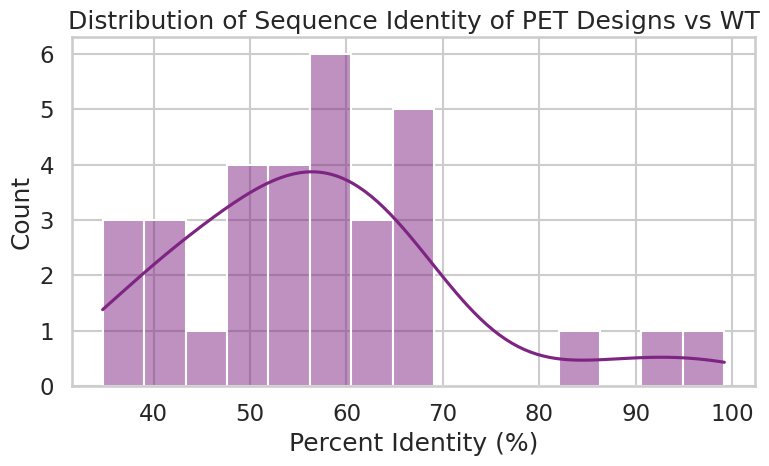

/tmp/ipykernel_1586149/733232141.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


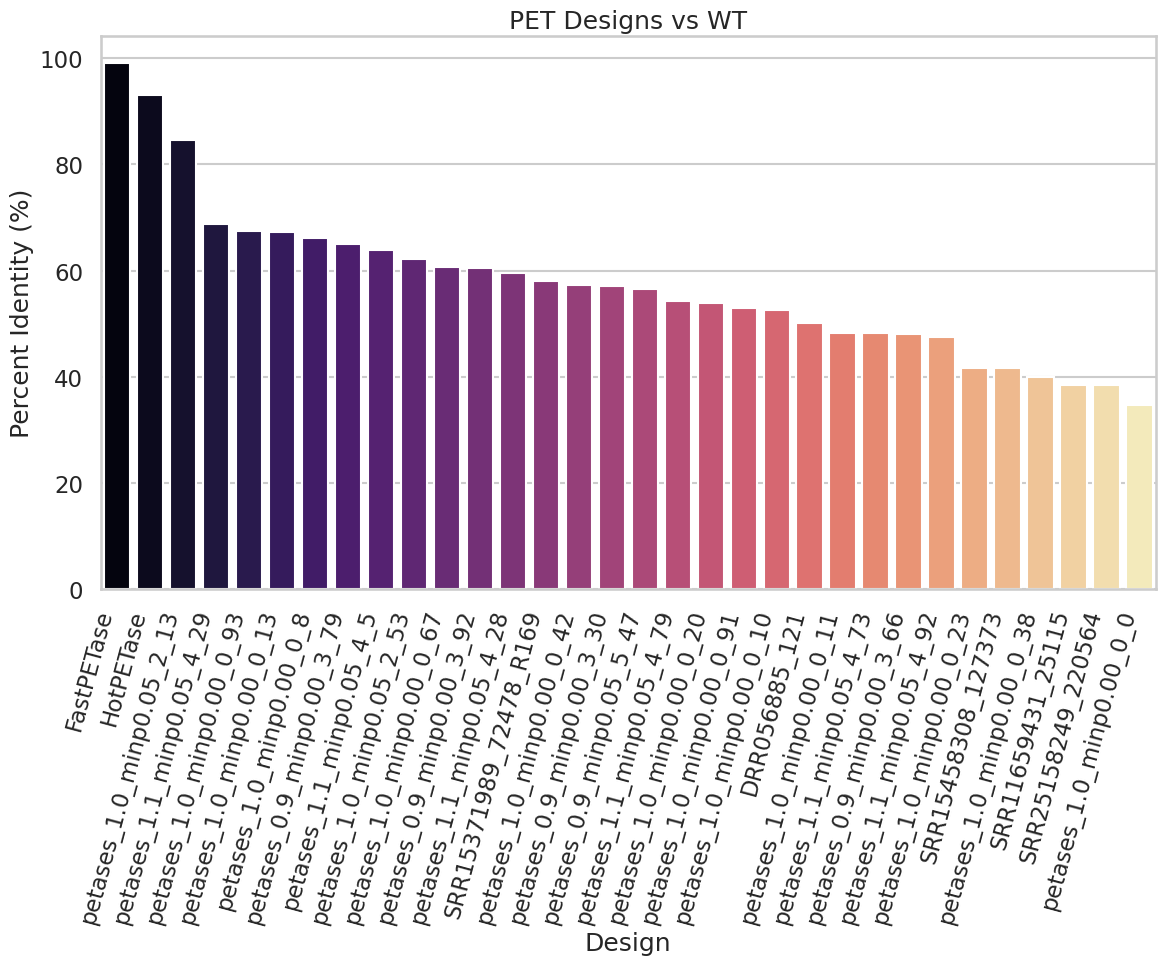

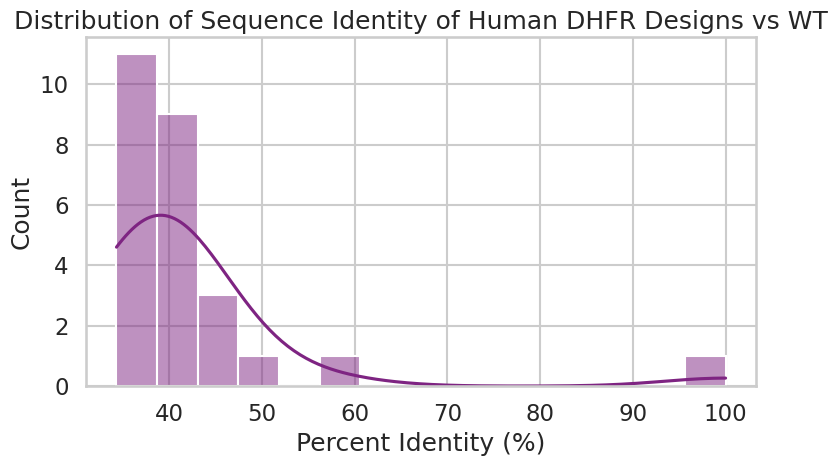

/tmp/ipykernel_1586149/733232141.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


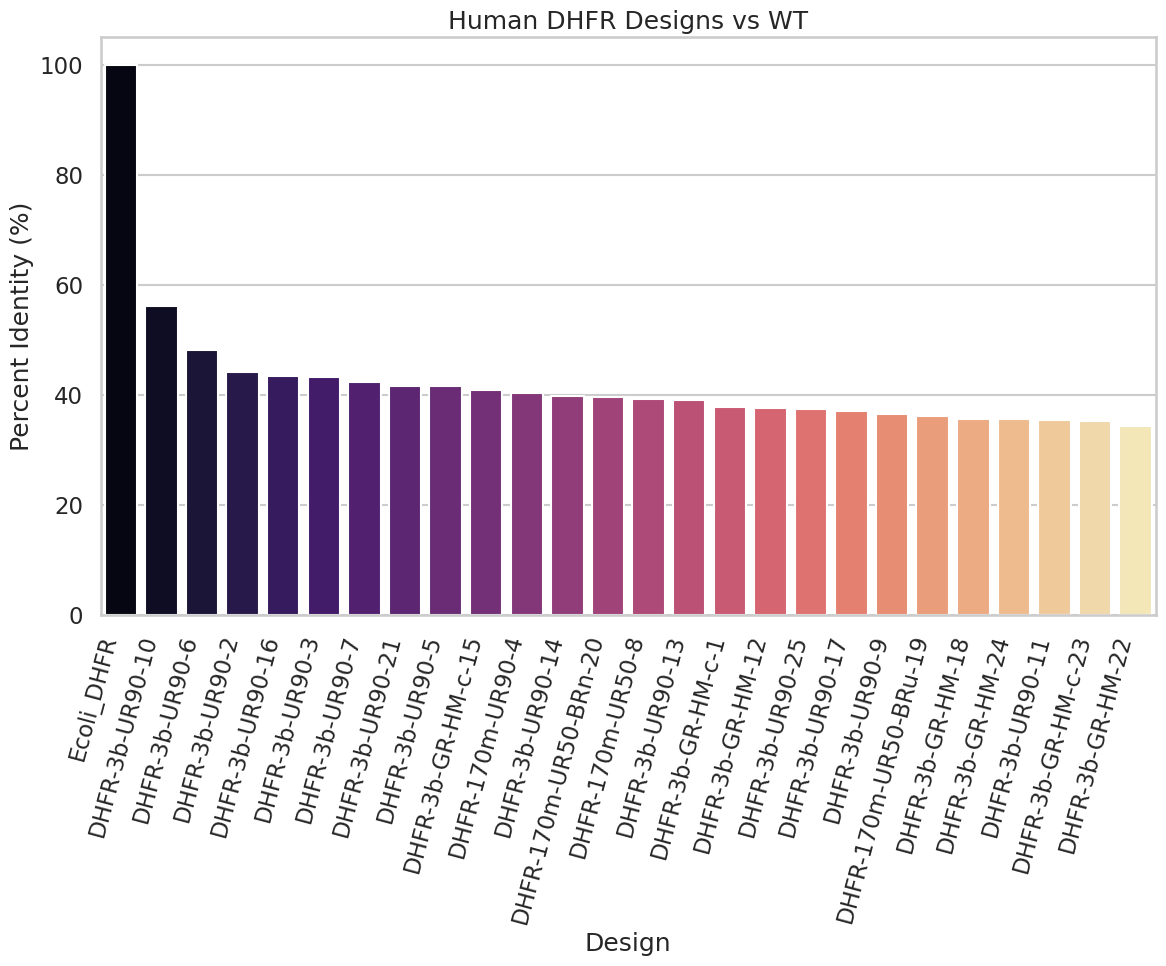

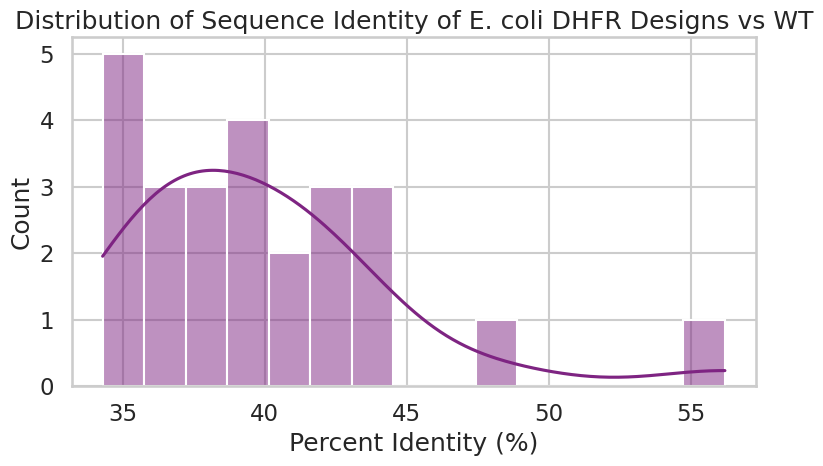

/tmp/ipykernel_1586149/733232141.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


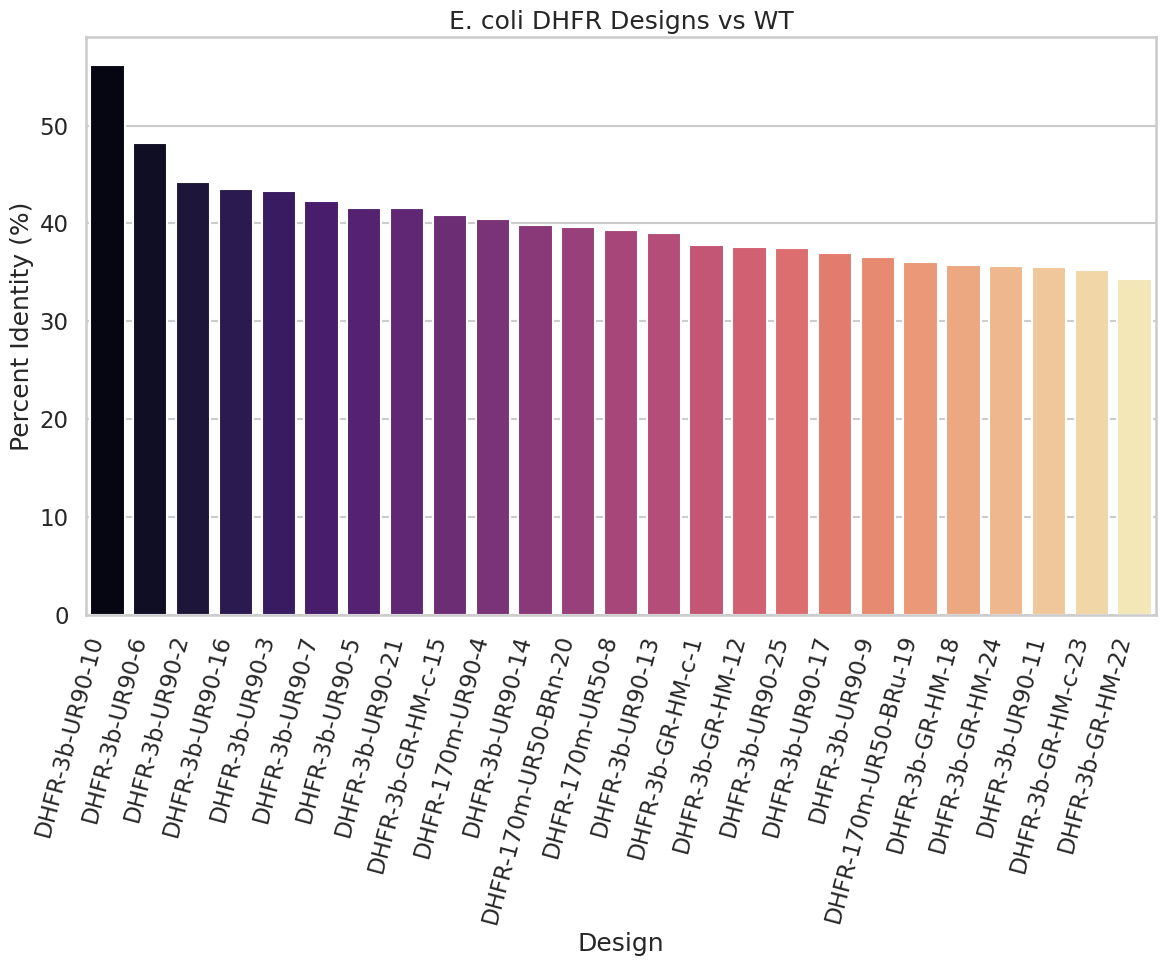

In [3]:

# pident — Percent Identity
# alnlen — Alignment Length
# qcov — Query Coverage
# tcov — Target Coverage
# evalue — E-value
# bits — Bit Score


PET_mmseqs_results = pd.read_csv("PET_mmseqs_results.tsv", sep="\t",
                 names=["query", "target", "pident", "alnlen", "qcov", "tcov", "evalue", "bits"])
DHFR_mmseqs_results = pd.read_csv("DHFR_mmseqs_results.tsv", sep="\t",
                 names=["query", "target", "pident", "alnlen", "qcov", "tcov", "evalue", "bits"])
Ecoli_DHFR_mmseqs_results = pd.read_csv("Ecoli_DHFR_mmseqs_results.tsv", sep="\t",
                 names=["query", "target", "pident", "alnlen", "qcov", "tcov", "evalue", "bits"])

def plot_mmseqs_results(df, palette="viridis", title=None):
    """
    Creates:
      1. Histogram of percent identity
      2. Barplot of identity sorted by similarity
    """

    # --- Style ---
    sns.set(style="whitegrid", context="talk")

    # --- Figure 1: Histogram ---
    plt.figure(figsize=(8, 5))
    sns.histplot(df["pident"], bins=15, kde=True, color=sns.color_palette(palette, 10)[3])
    plt.xlabel("Percent Identity (%)")
    plt.ylabel("Count")
    plt.title(f"Distribution of Sequence Identity of {title}")
    plt.tight_layout()
    plt.show()

    # --- Figure 2: Barplot ---
    sorted_df = df.sort_values("pident", ascending=False)

    plt.figure(figsize=(12, 10))
    sns.barplot(
        data=sorted_df,
        x="query",
        y="pident",
        palette=sns.color_palette(palette, len(sorted_df))
    )

    # beautify axis labels
    plt.xticks(rotation=75, ha="right")
    plt.ylabel("Percent Identity (%)")
    plt.xlabel("Design")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_mmseqs_results(PET_mmseqs_results, palette="magma", title = "PET Designs vs WT")
plot_mmseqs_results(DHFR_mmseqs_results, palette="magma", title = "Human DHFR Designs vs WT")
plot_mmseqs_results(Ecoli_DHFR_mmseqs_results, palette="magma", title = "E. coli DHFR Designs vs WT")
